In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [80]:
df = pd.read_csv("../data/merged_clean.csv")

In [81]:
df.shape
df.head()

,QKEY,COVIDMISINFO_W63.5,COVIDCREATE_W63.5,F_PARTYSUM_FINAL,F_IDEO,F_AGECAT,F_EDUCCAT,WEIGHT_W63.5,VOTEGEN_POST_W78,covid_misinfo_belief,trump_vote,trump_vote_2016
0,100197.0,Some,Not sure,Dem/Lean Dem,Moderate,65+,Some College,0.326265,"Joe Biden, the Democrat",NaN,0.0,0.0
1,100260.0,Some,Was developed intentionally in a lab,Rep/Lean Rep,Very conservative,65+,College graduate+,0.655627,"Donald Trump, the Republican",1.0,1.0,1.0
2,100314.0,Not much,Was made accidentally in a lab,Rep/Lean Rep,Moderate,65+,Some College,0.432865,"Donald Trump, the Republican",NaN,1.0,1.0
3,100363.0,None at all,Came about naturally,Dem/Lean Dem,Moderate,30-49,College graduate+,0.396183,"Joe Biden, the Democrat",0.0,0.0,1.0
4,100446.0,Not much,Not sure,Dem/Lean Dem,Liberal,50-64,College graduate+,0.392344,"Joe Biden, the Democrat",NaN,0.0,0.0


**Regression model 1**

In [82]:
reg1 = df[["covid_misinfo_belief", "trump_vote"]].dropna()
reg1.shape

(5079, 2)

In [83]:
reg1.trump_vote.value_counts()
reg1.covid_misinfo_belief.value_counts()

covid_misinfo_belief
0.0    3943
1.0    1136
Name: count, dtype: int64

In [84]:
# run model
model1 = smf.logit("trump_vote ~ covid_misinfo_belief", data=reg1).fit()

Optimization terminated successfully.
         Current function value: 0.590116
         Iterations 5


In [85]:
model1.summary()
# positve coefficient 1.6765 -> 1 respondents (misinfo) more likely to vote for Trump than 0 (came naturally)
# small p value (<0.001) -> statistically significant

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 5079
Model:                          Logit   Df Residuals:                     5077
Method:                           MLE   Df Model:                            1
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.08775
Time:                        18:07:57   Log-Likelihood:                -2997.2
converged:                       True   LL-Null:                       -3285.5
Covariance Type:            nonrobust   LLR p-value:                2.073e-127
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.0396      0.036    -28.678      0.000      -1.111      -0.969
covid_misinfo_belief     1.6765      0.072     23.239      0.000       1.535       1.818
========================================================================================
"""

In [86]:
np.exp(model1.params) # exponentiate coefficient
# odds of voting for Trump are about 5.35x as high for misinfo believers

Intercept               0.353587
covid_misinfo_belief    5.346869
dtype: float64

**Regression model 2 - control for political party (check for confounding in model 1)**

In [87]:
df["F_PARTYSUM_FINAL"].value_counts(dropna=False)

reg2 = df[["trump_vote", "covid_misinfo_belief", "F_PARTYSUM_FINAL"]].dropna()
reg2.shape

(5079, 3)

In [88]:
model2 = smf.logit('trump_vote ~ covid_misinfo_belief + C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))', data=reg2).fit()
model2.summary()

# coefficient drops to 1.2816 - still positive and statistically significant (p < 0.001)

Optimization terminated successfully.
         Current function value: 0.189497
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 5079
Model:                          Logit   Df Residuals:                     5075
Method:                           MLE   Df Model:                            3
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.7071
Time:                        18:08:06   Log-Likelihood:                -962.46
converged:                       True   LL-Null:                       -3285.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================================================================
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         -4.0937      0.133    -30.699      0.000      -4.355      -3.832
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]     2.3954      0.346      6.919      0.000       1.717       3.074
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]           5.8419      0.147     39.787      0.000       5.554       6.130
covid_misinfo_belief                                                               1.2816      0.153      8.386      0.000       0.982       1.581
==================================================================================================================================================
"""

In [89]:
# exponentiate coefficient
np.exp(model2.params)
# odds of voting for Trump are about 3.6x as high for misinfo believers after controlling for politcal affiliations
# republican coefficient was 5.8419 - explains confounding in model 1

Intercept                                                                           0.016677
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]     10.972674
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]          344.429452
covid_misinfo_belief                                                                3.602282
dtype: float64

**Calculating predicted probabilities from model 2**

In [90]:
# for each party, predicted probability of voting for Trump if believed/didn't believe misinformation

# data frame
pred_df = pd.DataFrame({"covid_misinfo_belief": [0, 1, 0, 1, 0, 1], "F_PARTYSUM_FINAL": ["Dem/Lean Dem", "Dem/Lean Dem",
                                                                                         "Rep/Lean Rep", "Rep/Lean Rep",
                                                                                         "DK/Refused/No lean", "DK/Refused/No lean"]})

pred_df

,covid_misinfo_belief,F_PARTYSUM_FINAL
0,0,Dem/Lean Dem
1,1,Dem/Lean Dem
2,0,Rep/Lean Rep
3,1,Rep/Lean Rep
4,0,DK/Refused/No lean
5,1,DK/Refused/No lean


In [91]:
# adding predictions to df

pred_df["predicted_prob"] = model2.predict(pred_df)
pred_df

,covid_misinfo_belief,F_PARTYSUM_FINAL,predicted_prob
0,0,Dem/Lean Dem,0.016404
1,1,Dem/Lean Dem,0.056672
2,0,Rep/Lean Rep,0.851724
3,1,Rep/Lean Rep,0.953900
4,0,DK/Refused/No lean,0.154688
5,1,DK/Refused/No lean,0.397300


**Plotting grouped bar chart from pred_df**

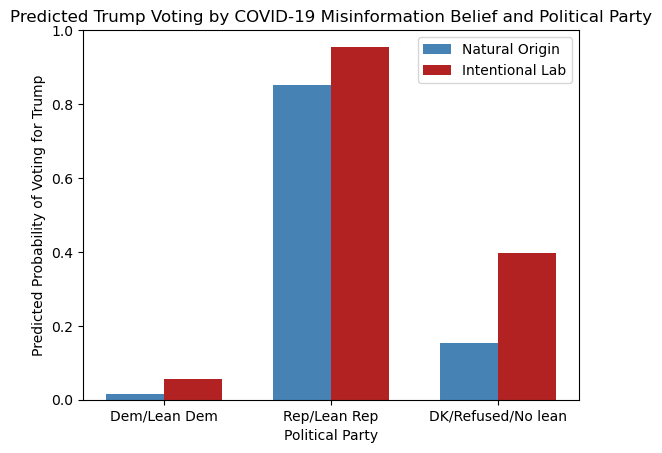

In [92]:
# separate misinfo belief into two groups
natural = pred_df[pred_df["covid_misinfo_belief"] == 0]
intentional = pred_df[pred_df["covid_misinfo_belief"] == 1]

# bar positions
x = np.arange(len(natural))
width = 0.35

# two sets of bars
plt.bar(x - width/2, natural["predicted_prob"], width, label="Natural Origin", color="steelblue")
plt.bar(x + width/2, intentional["predicted_prob"], width, label="Intentional Lab", color="firebrick")


plt.xticks(x, natural["F_PARTYSUM_FINAL"])
plt.xlabel("Political Party")
plt.ylabel("Predicted Probability of Voting for Trump")
plt.title("Predicted Trump Voting by COVID-19 Misinformation Belief and Political Party")
plt.legend()
plt.ylim(0, 1) # probabilities can only range from 0-1

plt.savefig("../output/predicted_trump_vote.png", bbox_inches="tight")

plt.show()

**Coefficient/forest plot**

In [93]:
np.exp(model1.params)
np.exp(model2.params)

Intercept                                                                           0.016677
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]     10.972674
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]          344.429452
covid_misinfo_belief                                                                3.602282
dtype: float64

In [94]:
# confidence intervals (95%)

np.exp(model1.conf_int())
np.exp(model2.conf_int())
# neither confidence interval includes 1 -> both have statistically significant association

,0,1
Intercept,0.012842,0.021659
"C(F_PARTYSUM_FINAL, Treatment(reference=""Dem/Lean Dem""))[T.DK/Refused/No lean]",5.566934,21.627626
"C(F_PARTYSUM_FINAL, Treatment(reference=""Dem/Lean Dem""))[T.Rep/Lean Rep]",258.296448,459.284856
covid_misinfo_belief,2.669939,4.860199


In [95]:
# do what I just did manually to create lists of each parameter

models = [model1, model2]
labels = ["Unadjusted", "Adjusted for party"]

odds_ratios = []
ci_lower = []
ci_upper = []

for model in models:
    # exponentiate coefficients
    odds_ratios.append(np.exp(model.params["covid_misinfo_belief"]))
    # get confidence intervals
    ci = model.conf_int().loc["covid_misinfo_belief"]
    # get confidence interval bounds
    ci_lower.append(np.exp(ci[0]))
    ci_upper.append(np.exp(ci[1]))

odds_ratios, ci_lower, ci_upper

([np.float64(5.346868746757617), np.float64(3.6022818449114995)],
 [np.float64(4.641853629628083), np.float64(2.6699387268239914)],
 [np.float64(6.158963137608454), np.float64(4.8601993595617206)])

In [96]:
# error bar distances from center point
lower_error = np.array(odds_ratios) - np.array(ci_lower)
upper_error = np.array(ci_upper) - np.array(odds_ratios)

errors = [lower_error, upper_error]

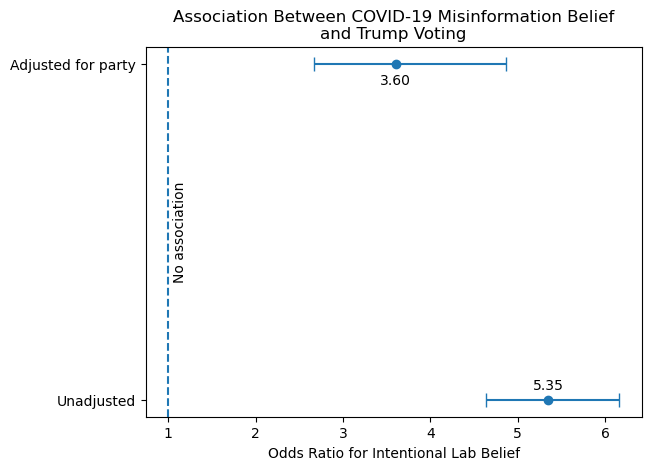

In [97]:
# plot

y = np.arange(len(labels)) # get the two vertical positions for the two models

# dot is the odds ratio, error bars is the 95% confidence interval
plt.errorbar(odds_ratios, y, xerr=errors, fmt="o", capsize=5) # points look like "o", and add ends to confidence intervals
plt.yticks(y, labels)
plt.axvline(x=1, linestyle="--") # show line of no association
plt.text(1.05, 0.5, "No association", rotation=90, va="center") # and label it
# label odds ratios
plt.text(odds_ratios[0], y[0] + 0.03, f"{odds_ratios[0]:.2f}", ha="center") # rounded to 2 decimal places
plt.text(odds_ratios[1], y[1] - 0.06, f"{odds_ratios[1]:.2f}", ha="center")
plt.xlabel("Odds Ratio for Intentional Lab Belief")
plt.title("Association Between COVID-19 Misinformation Belief\nand Trump Voting")

plt.savefig("../output/forest_coefficient_plot.png", bbox_inches="tight")
plt.show()

**Regression model 3 - control for age & education**

In [98]:
df.columns

Index(['QKEY', 'COVIDMISINFO_W63.5', 'COVIDCREATE_W63.5', 'F_PARTYSUM_FINAL',
       'F_IDEO', 'F_AGECAT', 'F_EDUCCAT', 'WEIGHT_W63.5', 'VOTEGEN_POST_W78',
       'covid_misinfo_belief', 'trump_vote', 'trump_vote_2016'],
      dtype='object')

In [99]:
df["F_AGECAT"].value_counts(dropna=False)
df["F_EDUCCAT"].value_counts(dropna=False)

F_EDUCCAT
College graduate+        4532
Some College             2236
H.S. graduate or less    1028
Refused                    10
Name: count, dtype: int64

In [100]:
reg3 = df[["trump_vote", "covid_misinfo_belief", "F_PARTYSUM_FINAL", "F_AGECAT", "F_EDUCCAT"]].dropna()
reg3 = reg3[(reg3["F_AGECAT"] != "Refused") & (reg3["F_EDUCCAT"] != "Refused")]

reg3.shape
# 5068 respondents

(5068, 5)

In [101]:
model3 = smf.logit('''trump_vote ~ covid_misinfo_belief + C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))
                                                        + C(F_AGECAT, Treatment(reference="18-29"))
                                                        + C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))''',
                   data=reg3).fit()

model3.summary()
# coefficient drops to 1.1774 - still positive and statistically significant (p < 0.001)

Optimization terminated successfully.
         Current function value: 0.183519
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 5068
Model:                          Logit   Df Residuals:                     5059
Method:                           MLE   Df Model:                            8
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.7163
Time:                        18:09:22   Log-Likelihood:                -930.07
converged:                       True   LL-Null:                       -3278.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================================================================
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                          -3.7970      0.332    -11.429      0.000      -4.448      -3.146
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]      2.2532      0.355      6.344      0.000       1.557       2.949
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]            5.8652      0.152     38.700      0.000       5.568       6.162
C(F_AGECAT, Treatment(reference="18-29"))[T.30-49]                                  0.3256      0.283      1.152      0.249      -0.228       0.879
C(F_AGECAT, Treatment(reference="18-29"))[T.50-64]                                  0.5158      0.277      1.862      0.063      -0.027       1.059
C(F_AGECAT, Treatment(reference="18-29"))[T.65+]                                    0.5941      0.281      2.116      0.034       0.044       1.144
C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))[T.College graduate+]    -1.0317      0.222     -4.641      0.000      -1.467      -0.596
C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))[T.Some College]         -0.4100      0.237     -1.732      0.083      -0.874       0.054
covid_misinfo_belief                                                                1.1774      0.156      7.533      0.000       0.871       1.484
===================================================================================================================================================
"""

In [102]:
np.exp(model3.params["covid_misinfo_belief"])
# odds of voting for Trump are about 3.25x as high for misinfo believers after controlling for party, age, and education

np.float64(3.246042124887441)

**Coefficient/forest plot**

In [103]:
np.exp(model3.conf_int().loc["covid_misinfo_belief"])

0    2.389545
1    4.409537
Name: covid_misinfo_belief, dtype: float64

In [104]:
models = [model1, model2, model3]
labels = ["Unadjusted", "Adjusted for party", "Adjusted for party, age & education"]
odds_ratios = []
ci_lower = []
ci_upper = []

for model in models:
    # exponentiate coefficients
    odds_ratios.append(np.exp(model.params["covid_misinfo_belief"]))
    # get confidence intervals
    ci = model.conf_int().loc["covid_misinfo_belief"]
    # get confidence interval bounds
    ci_lower.append(np.exp(ci[0]))
    ci_upper.append(np.exp(ci[1]))


odds_ratios, ci_lower, ci_upper

([np.float64(5.346868746757617),
  np.float64(3.6022818449114995),
  np.float64(3.246042124887441)],
 [np.float64(4.641853629628083),
  np.float64(2.6699387268239914),
  np.float64(2.389545492103884)],
 [np.float64(6.158963137608454),
  np.float64(4.8601993595617206),
  np.float64(4.409537090363833)])

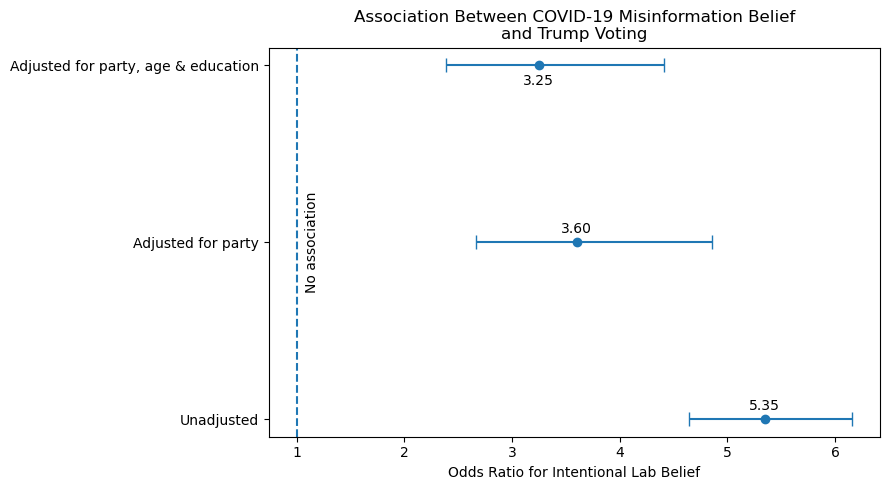

In [105]:
y = np.arange(len(labels))

# error bar distances from center point
lower_error = np.array(odds_ratios) - np.array(ci_lower)
upper_error = np.array(ci_upper) - np.array(odds_ratios)
errors = [lower_error, upper_error]

plt.figure(figsize=(9, 5)) # resize

plt.errorbar(odds_ratios, y, xerr=errors, fmt="o", capsize=5)

# line representing an odds ratio of 1
plt.axvline(1, linestyle="--")

plt.yticks(y, labels)
plt.xlabel("Odds Ratio for Intentional Lab Belief")
plt.title("Association Between COVID-19 Misinformation Belief\n"
          "and Trump Voting")

plt.text(1.08, 1, "No association", rotation=90, va="center")

# label each point with its odds ratio
plt.text(odds_ratios[0], y[0] + 0.05, f"{odds_ratios[0]:.2f}", ha="center") # rounded to 2 decimal places
plt.text(odds_ratios[1], y[1] + 0.05, f"{odds_ratios[1]:.2f}", ha="center")
plt.text(odds_ratios[2], y[2] - 0.11, f"{odds_ratios[2]:.2f}", ha="center")

plt.tight_layout() # adjust spacing
plt.savefig("../output/forest_coefficient_plot2.png", bbox_inches="tight")
plt.show()

**Regression model 4 - compare to 2016 vote**

In [106]:
reg4 = df[(df["F_AGECAT"] != "Refused") & (df["F_EDUCCAT"] != "Refused")][["trump_vote",
                                                                           "covid_misinfo_belief",
                                                                           "F_PARTYSUM_FINAL",
                                                                           "F_AGECAT",
                                                                           "F_EDUCCAT",
                                                                           "trump_vote_2016"]].dropna()

reg4.shape # 1406

(1406, 6)

In [107]:
model4 = smf.logit('''trump_vote ~ covid_misinfo_belief + C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))
                                                        + C(F_AGECAT, Treatment(reference="18-29"))
                                                        + C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))
                                                        + trump_vote_2016''',
                   data=reg4).fit()

model4.summary()
# coef = 2.1290

Optimization terminated successfully.
         Current function value: 0.072076
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 1406
Model:                          Logit   Df Residuals:                     1396
Method:                           MLE   Df Model:                            9
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.8909
Time:                        18:09:53   Log-Likelihood:                -101.34
converged:                       True   LL-Null:                       -928.48
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================================================================
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                          -3.2154      1.328     -2.421      0.015      -5.819      -0.612
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]      3.0741      1.574      1.953      0.051      -0.012       6.160
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]            4.6761      0.553      8.454      0.000       3.592       5.760
C(F_AGECAT, Treatment(reference="18-29"))[T.30-49]                                 -1.9147      1.288     -1.487      0.137      -4.439       0.610
C(F_AGECAT, Treatment(reference="18-29"))[T.50-64]                                 -1.7146      1.264     -1.356      0.175      -4.192       0.763
C(F_AGECAT, Treatment(reference="18-29"))[T.65+]                                   -1.6339      1.277     -1.280      0.201      -4.136       0.869
C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))[T.College graduate+]    -2.1982      0.770     -2.854      0.004      -3.708      -0.688
C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))[T.Some College]         -2.0292      0.807     -2.515      0.012      -3.611      -0.448
covid_misinfo_belief                                                                2.1290      0.600      3.547      0.000       0.952       3.305
trump_vote_2016                                                                     5.2225      0.587      8.890      0.000       4.071       6.374
===================================================================================================================================================
"""

In [108]:
np.exp(model4.params["covid_misinfo_belief"])
# rises to 8.4

np.float64(8.406085168934855)

In [109]:
# run model 3 on same sample as model 4 to see the difference (because of large difference in sample size)

model3_subsample = smf.logit('''trump_vote ~ covid_misinfo_belief + C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))
                                                                  + C(F_AGECAT, Treatment(reference="18-29"))
                                                                  + C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))''',
                             data=reg4).fit()

model3_subsample.summary()
# coef = 1.5034

Optimization terminated successfully.
         Current function value: 0.115475
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 1406
Model:                          Logit   Df Residuals:                     1397
Method:                           MLE   Df Model:                            8
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.8251
Time:                        18:10:21   Log-Likelihood:                -162.36
converged:                       True   LL-Null:                       -928.48
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================================================================
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                          -3.6749      1.413     -2.600      0.009      -6.445      -0.905
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]      4.1927      1.094      3.831      0.000       2.048       6.338
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]            7.4005      0.448     16.532      0.000       6.523       8.278
C(F_AGECAT, Treatment(reference="18-29"))[T.30-49]                                 -1.0269      1.327     -0.774      0.439      -3.627       1.573
C(F_AGECAT, Treatment(reference="18-29"))[T.50-64]                                 -0.2222      1.314     -0.169      0.866      -2.798       2.353
C(F_AGECAT, Treatment(reference="18-29"))[T.65+]                                   -0.1857      1.310     -0.142      0.887      -2.753       2.382
C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))[T.College graduate+]    -1.3327      0.634     -2.103      0.035      -2.575      -0.091
C(F_EDUCCAT, Treatment(reference="H.S. graduate or less"))[T.Some College]         -0.7584      0.674     -1.125      0.261      -2.080       0.563
covid_misinfo_belief                                                                1.5034      0.423      3.551      0.000       0.674       2.333
===================================================================================================================================================
"""

In [110]:
np.exp(model3_subsample.params["covid_misinfo_belief"])
# 4.5

np.float64(4.497033451259602)

**Coefficient/forest plot for models 3 and 4 from same sample**

In [111]:
models = [model3_subsample, model4]
labels = ["Party, age & education", "Party, age, education & 2016 vote"]

odds_ratios = []
ci_lower = []
ci_upper = []

for model in models:
    odds_ratios.append(np.exp(model.params["covid_misinfo_belief"]))
    ci = model.conf_int().loc["covid_misinfo_belief"]
    ci_lower.append(np.exp(ci[0]))
    ci_upper.append(np.exp(ci[1]))

odds_ratios, ci_lower, ci_upper


lower_error = np.array(odds_ratios) - np.array(ci_lower)
upper_error = np.array(ci_upper) - np.array(odds_ratios)
errors = [lower_error, upper_error]

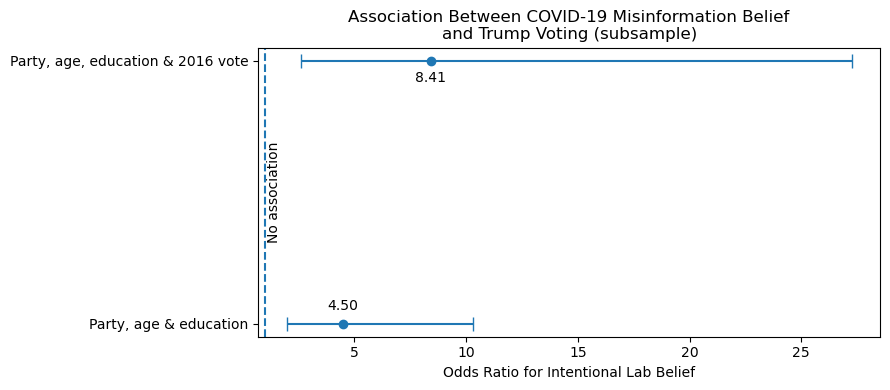

In [112]:
y = np.arange(len(models))

plt.figure(figsize=(9, 4))

plt.errorbar(odds_ratios, y, xerr=errors, fmt="o", capsize=5)

# line of no association
plt.axvline(x=1, linestyle="--")
# label the line
plt.text(1.1, 0.5, "No association", rotation=90, va="center")
plt.yticks(y, labels)
plt.xlabel("Odds Ratio for Intentional Lab Belief")
plt.title("Association Between COVID-19 Misinformation Belief\n"
          "and Trump Voting (subsample)")
plt.text(odds_ratios[0], y[0] + 0.05, f"{odds_ratios[0]:.2f}", ha="center")
plt.text(odds_ratios[1], y[1] - 0.08, f"{odds_ratios[1]:.2f}",ha="center")

plt.tight_layout()
plt.savefig("../output/forest_coefficient_plot3.png", bbox_inches="tight")
plt.show()